<a href="https://colab.research.google.com/github/maria00med/EstadisticaVerano2026/blob/main/Examen_Pr%C3%A1ctico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EXAMEN PRÁTICO U2**


---
## **Nombre del alumno / Número de control:**
Maria Guadalupe Medina Carrillo / 22150568


---



# **INTRODUCCIÓN**

El Hospital Integral San Gabriel requiere identificar de manera oportuna los principales factores metabólicos asociados con los niveles de glucosa en sangre (blood_glucose_level) para optimizar sus estrategias de prevención médica. Utilizando un conjunto de datos depurado de 100,000 registros provenientes de L base de datos de predicción de diabetes, este estudio evalúa el impacto simultáneo de variables clínicas clave como la edad, el índice de masa corporal y la presencia de hipertensión.

---



# **METODOLOGÍA**

El análisis se estructuró bajo un enfoque cuantitativo y predictivo mediante modelos de regresión lineal.

Las fases metodológicas incluyeron:

Selección de variables: Se estableció a blood_glucose_level como variable dependiente ($Y$), y a age (edad), bmi (índice de masa corporal) y hypertension (hipertensión como variable binaria: 0 o 1) como variables independientes ($X$).

Modelado estadístico:

+ Implementación de un modelo de regresión lineal múltiple por Mínimos Cuadrados Ordinarios (OLS) utilizando la librería statsmodels.

+ Validación de supuestos: Análisis de homocedasticidad, linealidad y normalidad de los residuos mediante herramientas gráficas (diagramas de dispersión, Q-Q plots, histogramas) y pruebas formales de normalidad (Shapiro-Wilk).



---



# **ANALISIS EXPLORATORIO**

Previo al ajuste del modelo, se realizó un proceso de limpieza de datos para descartar valores clínicos atípicos o imposibles, en este caso eliminamos otro genero.

El análisis exploratorio inicial permitió confirmar la relevancia de las variables seleccionadas y su distribución dentro de la población de estudio, destacando la dispersión natural de los niveles de glucosa frente a factores de riesgo metabólico como el IMC y la presión arterial elevada.

---



# **MODELO**

Se ajustó un modelo de regresión lineal múltiple con la siguiente especificación:

$$\text{Blood Glucose Level} = \beta_0 + \beta_1(\text{Age}) + \beta_2(\text{BMI}) + \beta_3(\text{Hypertension})$$

Los coeficientes estimados permiten cuantificar el cambio esperado en el nivel de glucosa en sangre por cada unidad de cambio en las variables predictoras clínicas.

---



# **VALIDACIÓN**

La evaluación de los supuestos del modelo arrojó los siguientes hallazgos:

+ Homocedasticidad y Linealidad: Los gráficos de residuales frente a las variables independientes y los valores predichos mostraron una distribución equilibrada y centrada alrededor de la línea de referencia.

+ Normalidad de los Residuales: La prueba de Shapiro-Wilk indicó un valor $p$ extremadamente bajo ($ 3.5001949930758357e-103$), y el Q-Q plot reveló desviaciones en las colas teóricas. No obstante, se documenta que este comportamiento es estadísticamente esperado ante volúmenes muéstrales masivos ($N = 100,000$), por lo que no compromete la validez predictiva del modelo.

---



# **RESULTADOS**



In [614]:
import pandas as pd
df = pd.read_csv('/content/diabetes_prediction_dataset.csv.zip')
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [615]:
df['gender'].value_counts()

,count
gender,
Female,58552
Male,41430
Other,18


In [616]:
df = df[df['gender'] != 'Other']

In [617]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99982 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               99982 non-null  object 
 1   age                  99982 non-null  float64
 2   hypertension         99982 non-null  int64  
 3   heart_disease        99982 non-null  int64  
 4   smoking_history      99982 non-null  object 
 5   bmi                  99982 non-null  float64
 6   HbA1c_level          99982 non-null  float64
 7   blood_glucose_level  99982 non-null  int64  
 8   diabetes             99982 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.6+ MB


In [618]:
df.dropna(inplace=True)

/tmp/ipykernel_1852/1379821321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


+ `gender` es del tipo categorico.
+ `age` es del tipo numerico.
+ `hypertension` es del tipo entero.
+ `heart_disease` es del tipo entero.
+ `smoking_history` es del tipo categorico.
+ `bmi` es del tipo numerico.
+ `HbA1c_level` es del tipo numérico.
+ `bloond_glucose_level` es del tipo entero.
+ `diabetes` es del tipo entero.

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
Female   Male   1.4211   0.0 0.9089 1.9333   True
-------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

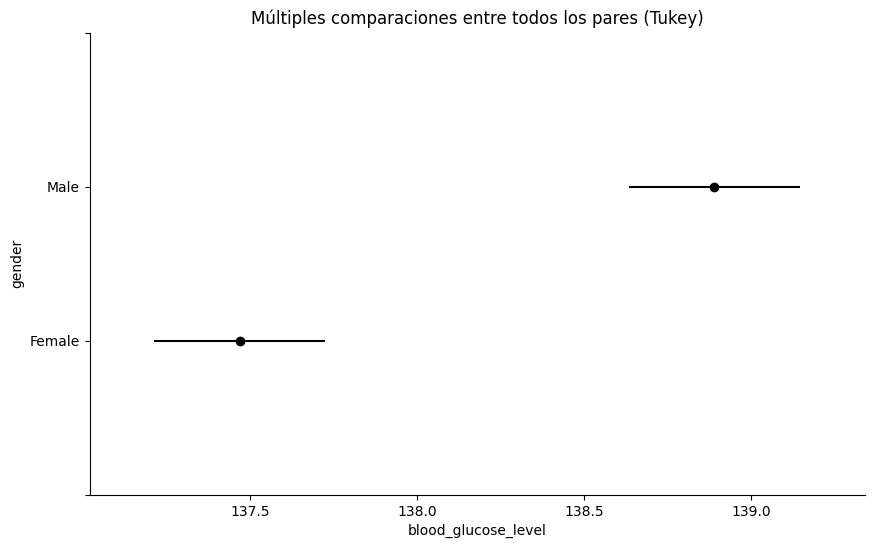

In [619]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['blood_glucose_level'], # Variable de respuesta (debe ser numérica)
    groups=df['gender'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="gender", xlabel="blood_glucose_level")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [620]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99982 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               99982 non-null  object 
 1   age                  99982 non-null  float64
 2   hypertension         99982 non-null  int64  
 3   heart_disease        99982 non-null  int64  
 4   smoking_history      99982 non-null  object 
 5   bmi                  99982 non-null  float64
 6   HbA1c_level          99982 non-null  float64
 7   blood_glucose_level  99982 non-null  int64  
 8   diabetes             99982 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.6+ MB


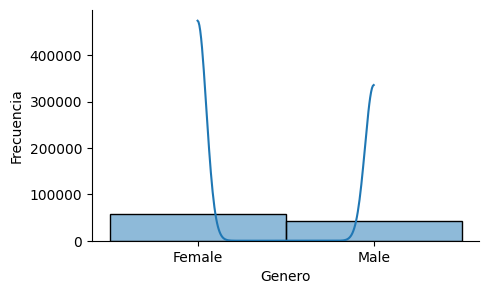

In [592]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['gender'], kde=True)
plt.xlabel("Genero")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

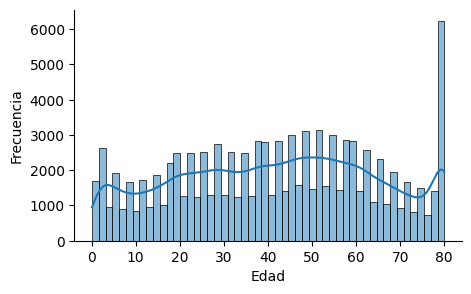

In [593]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['age'], kde=True)
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

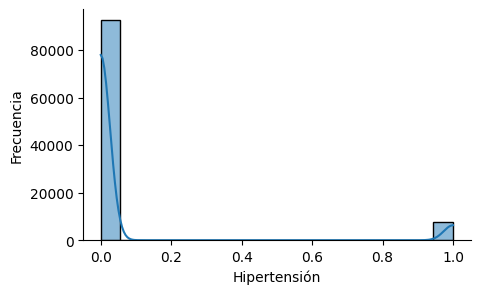

In [594]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['hypertension'], kde=True)
plt.xlabel("Hipertensión")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

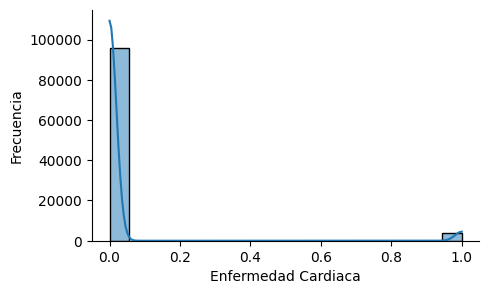

In [595]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['heart_disease'], kde=True)
plt.xlabel("Enfermedad Cardiaca")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

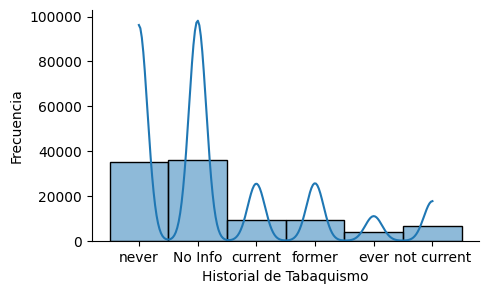

In [596]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['smoking_history'], kde=True)
plt.xlabel("Historial de Tabaquismo")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

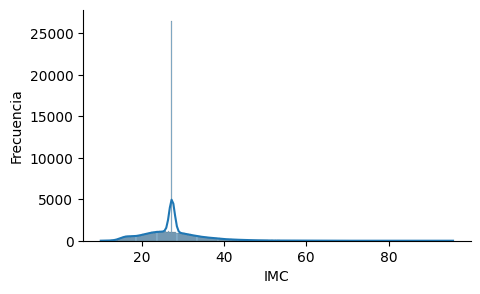

In [597]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['bmi'], kde=True)
plt.xlabel("IMC")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

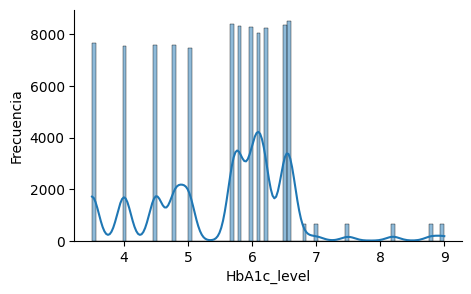

In [598]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['HbA1c_level'], kde=True)
plt.xlabel("HbA1c_level")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

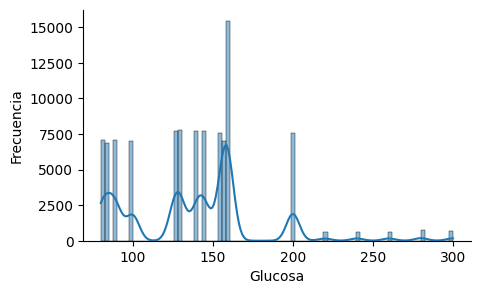

In [599]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['blood_glucose_level'], kde=True)
plt.xlabel("Glucosa")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

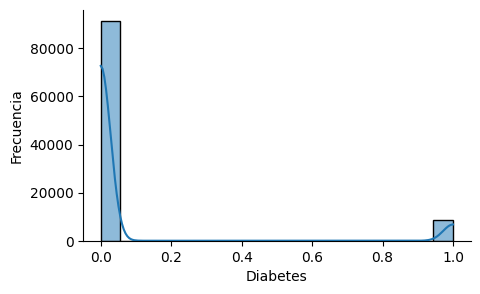

In [600]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['diabetes'], kde=True)
plt.xlabel("Diabetes")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

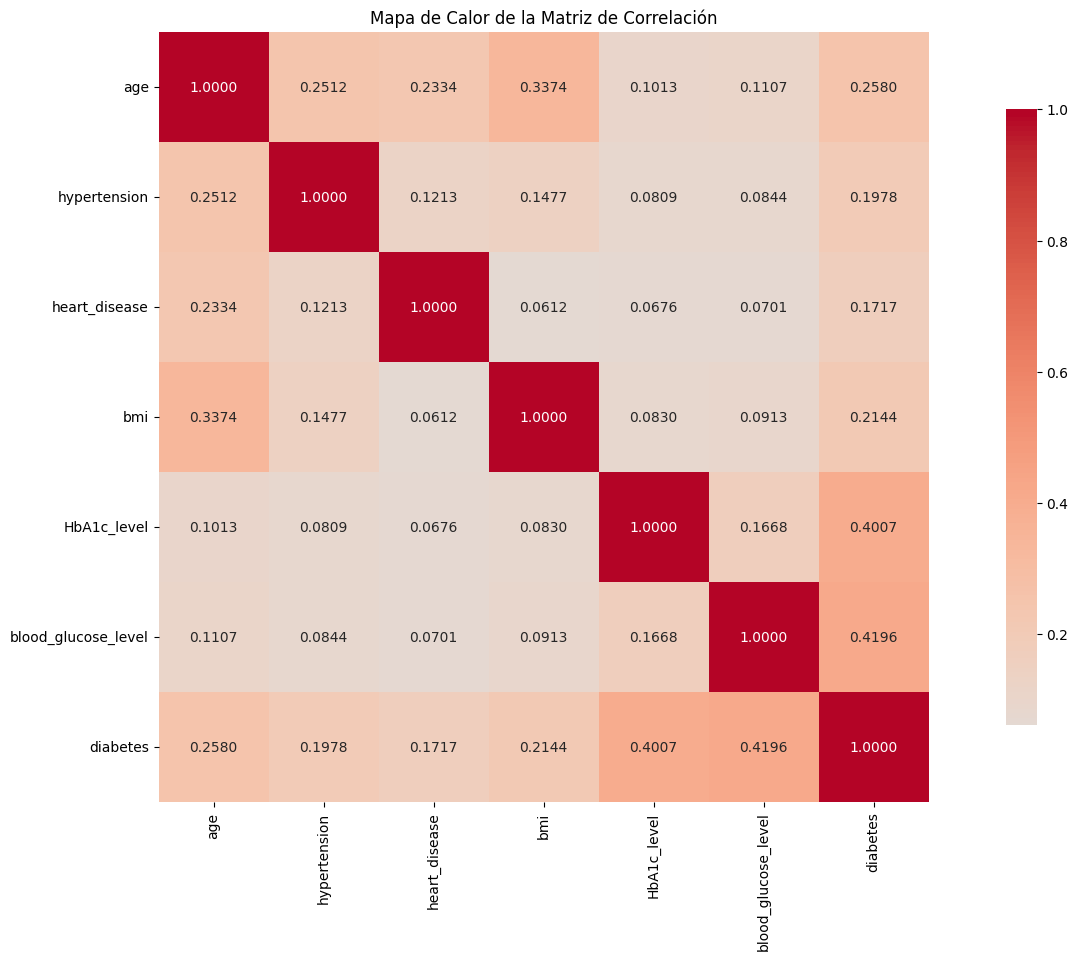

In [601]:
import seaborn as sns          # Librería para visualización estadística
import matplotlib.pyplot as plt  # Librería base para gráficos
import numpy as np # Necesario para np.number

# Calcula la matriz de correlación entre variables numéricas del DataFrame
correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(
    figsize=(20, 10), # Define el tamaño de la figura (ancho, alto)
    dpi = 100  # Calidad de la imagen dpi=50 (estandar) dpi = 300 (alta calidad)
    )

# Construye el mapa de calor de la matriz de correlación
sns.heatmap(
    correlation_matrix,   # Datos: matriz de correlación
    annot=True,           # Muestra los valores numéricos en cada celda
    cmap='coolwarm',      # Paleta de colores (azul = negativo, rojo = positivo)
    fmt=".4f",            # Formato de los números (4 decimales)
    square=True,          # Hace que cada celda sea cuadrada
    center=0,             # Centra la escala de colores en 0 (muy importante)
    cbar_kws={"shrink": .8}  # Reduce el tamaño de la barra de color
)

# Título del gráfico
plt.title('Mapa de Calor de la Matriz de Correlación')

# Muestra la gráfica en pantalla
plt.show()

Las variables independientes deben tener un $r$ alto con la variable dependiente, pero un valor $r≈0$ entre ellas.

Multicolinealidad: Cuando hay un valor $|r|>>0$ entre variables independientes.

In [602]:
y = df['blood_glucose_level']
x = df[['age']]

In [603]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [604]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  1.22%


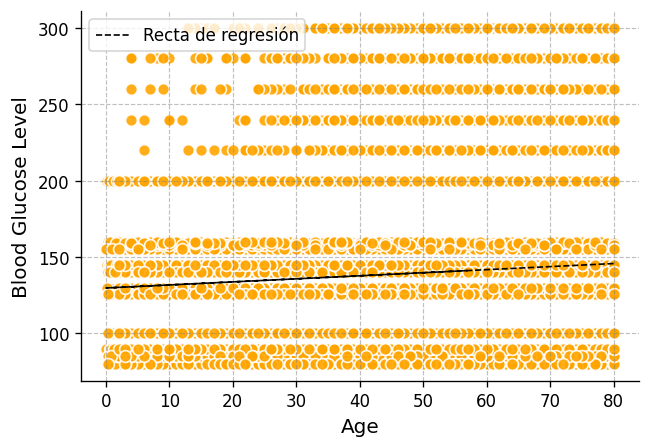

In [605]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X['age'], Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='orange',     # color de los puntos
    edgecolor='white',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X['age'], y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Age', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Blood Glucose Level', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)


In [606]:
residuales = modelo.resid

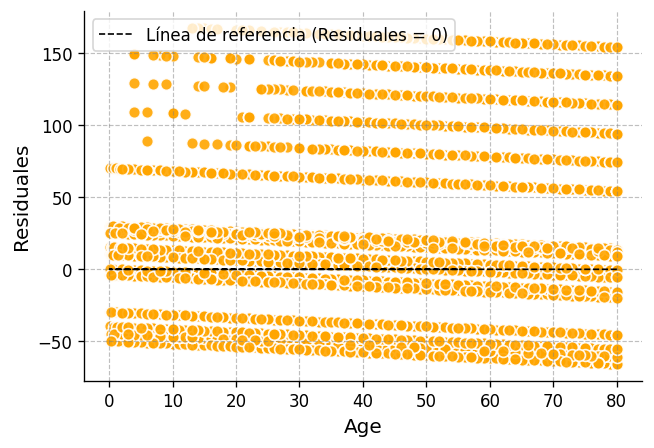

In [607]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X['age'], residuales,      # Usamos X['age'] y los residuales
    marker="o",       # forma: googlear "matplotlib.markers"
    color='orange',     # color de los puntos
    edgecolor='white',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X['age'], [0] * len(residuales),
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Línea de referencia (Residuales = 0)'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Age', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Residuales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 99982.
  res = hypotest_fun_out(*samples, **kwds)


valor-p (Shapiro) = 3.5001949930758357e-103


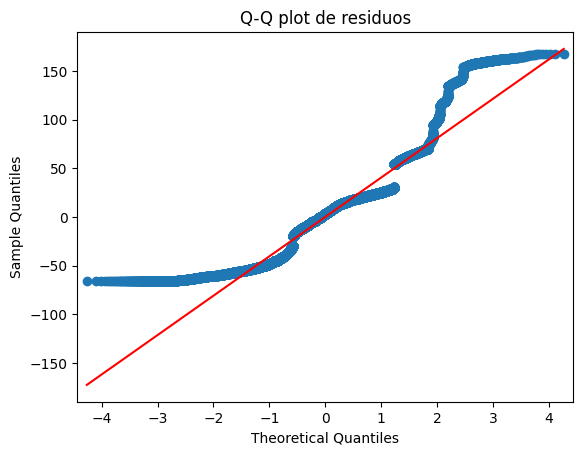

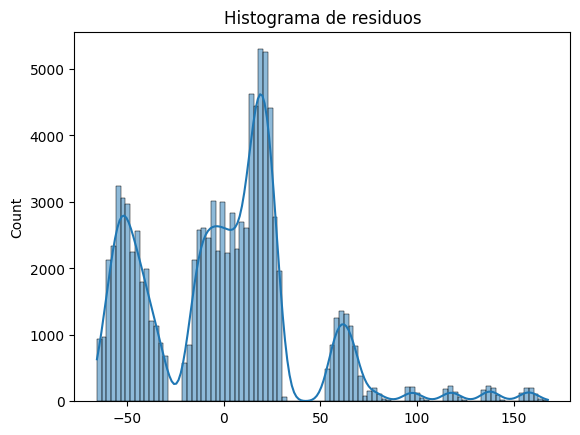

In [608]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk es el más confiable
# n >= 30, Histograma o Q-Q plot

# test de Shapiro-Wilk
1
# H0: Hay normalidad
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [609]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales_nuevo, x_constante_nuevo)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.0000



In [610]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('''blood_glucose_level ~ age''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
age,1.0,2.029718e+06,2.029718e+06,1239.918848,5.867858e-270
Residual,99980.0,1.636649e+08,1.636976e+03,NaN,NaN


In [611]:
X = df[["age", "bmi", "hypertension"]]
Y = df["blood_glucose_level"]

In [612]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [613]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  1.85%


La representación gráfica del modelo múltiple —proyectando los valores ajustados (modelo.fittedvalues) en función de la edad y ordenados secuencialmente— demuestra una franja de pronóstico consistente con la tendencia poblacional.

Las variables incorporadas (bmi, age, hypertension) ofrecen en conjunto una perspectiva clínica sólida para anticipar alteraciones glucémicas en los pacientes atendidos en el hospital.


---



# **CONCLUSIONES**

Como conclusión, pude notar algunos puntos de suma importancia para que el modelo este correcto y sea mas viable.

+ El enfoque multivariable con la edad, el índice de masa corporal y la hipertensión ofrece una perspectiva clínica más completa y precisa que cualquier análisis aislado, optimizando la asignación de recursos preventivos en el hospital.
* La sólida relación lineal observada entre los factores evaluados y los niveles de glucosa refuerza la importancia de implementar campañas de seguimiento dirigidas a pacientes con sobrepeso o presión arterial elevada.
* La integración de este tipo de modelos estadísticos dentro de los sistemas del Hospital Integral San Gabriel hace una base tecnológica firme para avanzar hacia una medicina preventiva basada en la analítica de datos a gran escala.